# Week 4 Notebook 04 | 完整教材版

## 三相 N-1 扫描与 Violation Label 设计

本 notebook 把 Week 3 的 base-case operating scenarios 扩展为 Week 5 机器学习、Week 6 physics-informed AI 和 Week 7 GNN 所需的监督学习数据集：

$$
(x_t, c_k) \longrightarrow y_{t,k},\; s_{t,k}
$$

其中：

- \(x_t\)：第 \(t\) 个 microgrid operating scenario；
- \(c_k\)：第 \(k\) 个 N-1 contingency；
- \(y_{t,k}\)：是否发生静态安全 violation；
- \(s_{t,k}\)：violation severity score。

本周的教学重点不是“跑出一个表”，而是让学生理解 **label 的工程含义** 和 **数据生成代码的可验证性**。因此本 notebook 每个关键步骤都配有 proof / cross-validation：

1. input network integrity proof；
2. contingency table schema proof；
3. base-case convergence proof；
4. N-0 reference cross-check；
5. state restoration proof；
6. service-loss detection proof；
7. label / severity consistency proof；
8. metric finiteness proof；
9. PCC outage non-convergence proof；
10. sentinel scan reproducibility proof。


## 0. 环境设置

需要的 Python 包：

```bash
pip install pandapower pandas numpy networkx matplotlib
```

本 notebook 使用 `pandapower.runpp_3ph()` 做三相不平衡潮流。对 N-1 计算，我们不用内置 contingency wrapper，而是手写 loop，因为微电网安全标签还需要 DER/BESS/PCC 跳闸、径向 feeder 失供检测、以及自定义 violation severity。


## Week 4 proof / cross-validation checklist

本 notebook 的正确性检查分成三类：

| 类型 | 检查内容 | 为什么重要 |
|---|---|---|
| 输入 proof | 网络表、三相参数、contingency catalog schema | 避免错误输入污染标签 |
| 物理 proof | base-case convergence、service-loss topology detection、PCC outage no-slack detection | 避免把拓扑问题误判成普通电压/电流问题 |
| 数据 proof | sample count、duplicate check、label consistency、sentinel reproducibility | 确保 Week 5 的 ML 数据集稳定可复现 |

课堂讲解建议：每个 proof 都要让学生先读断言条件，再运行代码。如果断言失败，优先修复数据生成逻辑，而不是直接调 AI 模型。


## Proof / cross-validation map

本 notebook 中的正确性检查分成两类：

**输入侧 proof**：保证网络、场景和 contingency catalog 本身没有结构性错误。

- input network integrity proof；
- contingency table schema proof；
- base-case convergence check；
- state restoration proof。

**标签侧 proof**：保证输出 label 与物理/拓扑逻辑一致。

- service-loss detection proof；
- label / severity consistency proof；
- converged rows metric finiteness proof；
- PCC outage non-convergence check；
- full N-1 scan reproducibility check。

这些检查的目的不是追求复杂，而是防止学生在生成 AI 标签时犯最常见的错误：状态没有恢复、PV/BESS 符号错、line outage 没有失供标签、post-contingency 结果泄露到 feature side。

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import warnings
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from IPython.display import display

try:
    import pandapower as pp
except ImportError as exc:
    raise ImportError("This notebook requires pandapower. Install it with `pip install pandapower`.") from exc

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

pd.set_option("display.max_columns", 140)
pd.set_option("display.width", 180)

SEED = 2026
rng = np.random.default_rng(SEED)


def find_course_root(start: Path | None = None) -> Path:
    """Locate the repository root whether Jupyter starts here or in notebooks/."""
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "environment.yml").exists() and (candidate / "00_overview").is_dir():
            return candidate
    raise FileNotFoundError(
        "Cannot locate the course repository root. Open this notebook from the cloned repository."
    )


PROJECT_ROOT = find_course_root()

OUTPUT_DIR = PROJECT_ROOT / "04_week04_three_phase_nminus1_labeling" / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PHASES = ["a", "b", "c"]
P_COLS = {ph: f"p_{ph}_mw" for ph in PHASES}
Q_COLS = {ph: f"q_{ph}_mvar" for ph in PHASES}
VM_COLS = [f"vm_{ph}_pu" for ph in PHASES]
VA_COLS = [f"va_{ph}_degree" for ph in PHASES]

# Teaching thresholds. Students can later replace these with utility/microgrid requirements.
V_MIN_PU = 0.95
V_MAX_PU = 1.05
VUF_MAX_PERCENT = 2.0
LINE_LOADING_MAX_PERCENT = 100.0
SERVICE_LOSS_EPS_MW = 1e-5

TOL_LABEL = 1e-12

print(f"pandapower version: {pp.__version__}")
print(f"Output directory: {OUTPUT_DIR.resolve()}")

pandapower version: 3.2.1
Output directory: /Users/buxinshe/Git-repo/PINN-Microgrid-Prediction/04_week04_three_phase_nminus1_labeling/outputs


## 1. 复用 Week 3 compact microgrid teaching feeder

为了让 Week 4 的 N-1 scanner 能在课堂内快速运行，本 notebook 继续使用 Week 3 的 compact microgrid teaching feeder。它不是某个真实 feeder 的精确模型，而是一个教学用的三相不平衡微电网 proxy：

- 0.4 kV PCC / slack equivalent；
- radial feeder；
- critical load、residential load、EV load、remote load、medical load；
- 单相 PV、三相 PV；
- BESS-like static setpoint。

科研扩展时，可以把 `create_microgrid_teaching_feeder()` 替换成完整的 `ieee_european_lv_asymmetric` feeder 或真实微电网模型，但保留本 notebook 的 validation suite。

In [2]:
@dataclass(frozen=True)
class MicrogridMetadata:
    bus_map: dict[str, int]
    line_names: list[str]
    original_load_indices: list[int]
    pv_config: pd.DataFrame
    bess_config: pd.DataFrame


def create_microgrid_teaching_feeder() -> tuple[pp.pandapowerNet, MicrogridMetadata]:
    """Create a compact three-phase microgrid feeder for Week 4 N-1 labeling."""
    net = pp.create_empty_network(name="week4_microgrid_teaching_feeder", sn_mva=1.0)

    bus_names = [
        "PCC_0p4kV",
        "Main_bus",
        "Critical_load_bus",
        "Residential_bus",
        "PV_A_bus",
        "PV_C_bus",
        "EV_bus",
        "Remote_bus",
        "Medical_bus",
    ]
    bus_map = {name: pp.create_bus(net, vn_kv=0.4, name=name) for name in bus_names}

    pp.create_ext_grid(
        net,
        bus=bus_map["PCC_0p4kV"],
        vm_pu=1.0,
        va_degree=0.0,
        name="PCC_slack_grid_connected",
        s_sc_max_mva=50.0,
        s_sc_min_mva=40.0,
        rx_max=0.10,
        rx_min=0.10,
        x0x_max=1.0,
        x0x_min=1.0,
        r0x0_max=0.10,
        r0x0_min=0.10,
    )

    line_specs = [
        ("PCC_0p4kV", "Main_bus", 0.020, "L0_PCC_to_main"),
        ("Main_bus", "Critical_load_bus", 0.030, "L1_main_to_critical"),
        ("Main_bus", "Residential_bus", 0.035, "L2_main_to_residential"),
        ("Residential_bus", "PV_A_bus", 0.030, "L3_residential_to_pvA"),
        ("Residential_bus", "PV_C_bus", 0.030, "L4_residential_to_pvC"),
        ("Critical_load_bus", "EV_bus", 0.035, "L5_critical_to_ev"),
        ("EV_bus", "Remote_bus", 0.040, "L6_ev_to_remote"),
        ("Critical_load_bus", "Medical_bus", 0.020, "L7_critical_to_medical"),
    ]
    line_names = []
    for from_name, to_name, length_km, name in line_specs:
        pp.create_line_from_parameters(
            net,
            from_bus=bus_map[from_name],
            to_bus=bus_map[to_name],
            length_km=length_km,
            r_ohm_per_km=0.642,
            x_ohm_per_km=0.083,
            c_nf_per_km=210.0,
            max_i_ka=0.25,
            r0_ohm_per_km=1.80,
            x0_ohm_per_km=0.25,
            c0_nf_per_km=70.0,
            name=name,
        )
        line_names.append(name)

    load_specs = [
        ("Critical_load_bus", (0.006, 0.005, 0.006), (0.0012, 0.0010, 0.0012), "critical_load"),
        ("Residential_bus", (0.005, 0.007, 0.004), (0.0010, 0.0014, 0.0008), "residential_load"),
        ("EV_bus", (0.003, 0.008, 0.003), (0.0006, 0.0016, 0.0006), "ev_b_phase_heavy_load"),
        ("Remote_bus", (0.004, 0.002, 0.005), (0.0008, 0.0004, 0.0010), "remote_load"),
        ("Medical_bus", (0.003, 0.004, 0.003), (0.0006, 0.0008, 0.0006), "medical_critical_load"),
    ]
    original_load_indices = []
    for bus_name, p_vals, q_vals, name in load_specs:
        idx = pp.create_asymmetric_load(
            net,
            bus=bus_map[bus_name],
            p_a_mw=p_vals[0], p_b_mw=p_vals[1], p_c_mw=p_vals[2],
            q_a_mvar=q_vals[0], q_b_mvar=q_vals[1], q_c_mvar=q_vals[2],
            type="wye",
            name=name,
        )
        original_load_indices.append(int(idx))

    pv_rows = []
    pv_specs = [
        ("PV_A_bus", "a", 0.006, "PV_single_phase_A"),
        ("PV_C_bus", "c", 0.006, "PV_single_phase_C"),
        ("Remote_bus", "abc", 0.006, "PV_three_phase_remote"),
    ]
    for bus_name, phase, rating_mw, name in pv_specs:
        idx = pp.create_asymmetric_sgen(
            net,
            bus=bus_map[bus_name],
            p_a_mw=0.0, p_b_mw=0.0, p_c_mw=0.0,
            q_a_mvar=0.0, q_b_mvar=0.0, q_c_mvar=0.0,
            type="wye",
            name=name,
        )
        pv_rows.append({"idx": int(idx), "bus": int(bus_map[bus_name]), "bus_name": bus_name, "phase": phase, "rating_mw": rating_mw, "name": name})

    bess_discharge_idx = pp.create_asymmetric_sgen(
        net,
        bus=bus_map["Critical_load_bus"],
        p_a_mw=0.0, p_b_mw=0.0, p_c_mw=0.0,
        q_a_mvar=0.0, q_b_mvar=0.0, q_c_mvar=0.0,
        type="wye",
        name="BESS_discharge_placeholder",
    )
    bess_charge_idx = pp.create_asymmetric_load(
        net,
        bus=bus_map["Critical_load_bus"],
        p_a_mw=0.0, p_b_mw=0.0, p_c_mw=0.0,
        q_a_mvar=0.0, q_b_mvar=0.0, q_c_mvar=0.0,
        type="wye",
        name="BESS_charge_placeholder",
    )
    bess_config = pd.DataFrame([
        {
            "discharge_sgen_idx": int(bess_discharge_idx),
            "charge_load_idx": int(bess_charge_idx),
            "bus": int(bus_map["Critical_load_bus"]),
            "bus_name": "Critical_load_bus",
            "rating_mw": 0.012,
            "name": "BESS_static_setpoint",
        }
    ])

    meta = MicrogridMetadata(
        bus_map=bus_map,
        line_names=line_names,
        original_load_indices=original_load_indices,
        pv_config=pd.DataFrame(pv_rows),
        bess_config=bess_config,
    )
    return net, meta


def clone_base_feeder():
    """Create a fresh feeder plus deep copies needed for reset-safe scanning."""
    net, meta = create_microgrid_teaching_feeder()
    return (
        net,
        meta,
        net.asymmetric_load.copy(deep=True),
        net.asymmetric_sgen.copy(deep=True),
        net.line.copy(deep=True),
        net.ext_grid.copy(deep=True),
    )


base_net, metadata, base_load_snapshot, base_sgen_snapshot, base_line_snapshot, base_ext_grid_snapshot = clone_base_feeder()

display(base_net.bus)
display(base_net.line[["name", "from_bus", "to_bus", "length_km", "max_i_ka", "r0_ohm_per_km", "x0_ohm_per_km"]])
display(base_net.asymmetric_load[["name", "bus", "p_a_mw", "p_b_mw", "p_c_mw"]])
display(base_net.asymmetric_sgen[["name", "bus", "p_a_mw", "p_b_mw", "p_c_mw"]])

,name,vn_kv,type,zone,in_service,geo
0,PCC_0p4kV,0.4,b,None,True,None
1,Main_bus,0.4,b,None,True,None
2,Critical_load_bus,0.4,b,None,True,None
3,Residential_bus,0.4,b,None,True,None
4,PV_A_bus,0.4,b,None,True,None
5,PV_C_bus,0.4,b,None,True,None
6,EV_bus,0.4,b,None,True,None
7,Remote_bus,0.4,b,None,True,None
8,Medical_bus,0.4,b,None,True,None


,name,from_bus,to_bus,length_km,max_i_ka,r0_ohm_per_km,x0_ohm_per_km
0,L0_PCC_to_main,0,1,0.020,0.25,1.8,0.25
1,L1_main_to_critical,1,2,0.030,0.25,1.8,0.25
2,L2_main_to_residential,1,3,0.035,0.25,1.8,0.25
3,L3_residential_to_pvA,3,4,0.030,0.25,1.8,0.25
4,L4_residential_to_pvC,3,5,0.030,0.25,1.8,0.25
5,L5_critical_to_ev,2,6,0.035,0.25,1.8,0.25
6,L6_ev_to_remote,6,7,0.040,0.25,1.8,0.25
7,L7_critical_to_medical,2,8,0.020,0.25,1.8,0.25


,name,bus,p_a_mw,p_b_mw,p_c_mw
0,critical_load,2,0.006,0.005,0.006
1,residential_load,3,0.005,0.007,0.004
2,ev_b_phase_heavy_load,6,0.003,0.008,0.003
3,remote_load,7,0.004,0.002,0.005
4,medical_critical_load,8,0.003,0.004,0.003
5,BESS_charge_placeholder,2,0.000,0.000,0.000


,name,bus,p_a_mw,p_b_mw,p_c_mw
0,PV_single_phase_A,4,0.0,0.0,0.0
1,PV_single_phase_C,5,0.0,0.0,0.0
2,PV_three_phase_remote,7,0.0,0.0,0.0
3,BESS_discharge_placeholder,2,0.0,0.0,0.0


### Proof check 1: input network integrity

三相 N-1 label 生成的第一步，是证明基础网络输入表没有明显错误：

1. element 引用的 bus 必须存在；
2. line 必须有正序和零序参数；
3. feeder 拓扑必须连通；
4. teaching feeder 预期是径向的；
5. PV 和 BESS metadata 必须能对应到 pandapower 元件表。

In [3]:
def build_feeder_graph(net: pp.pandapowerNet) -> nx.Graph:
    G = nx.Graph()
    for bus in net.bus.index.astype(int):
        G.add_node(int(bus))
    for line_idx, row in net.line.iterrows():
        if bool(row.get("in_service", True)):
            G.add_edge(int(row.from_bus), int(row.to_bus), element="line", index=int(line_idx))
    return G


def assert_input_network_integrity(net: pp.pandapowerNet, meta: MicrogridMetadata) -> dict:
    required_tables = ["bus", "line", "ext_grid", "asymmetric_load", "asymmetric_sgen"]
    for table in required_tables:
        assert hasattr(net, table), f"Missing net.{table}"

    bus_set = set(net.bus.index.astype(int))
    assert set(net.line.from_bus.astype(int)).issubset(bus_set)
    assert set(net.line.to_bus.astype(int)).issubset(bus_set)
    assert set(net.asymmetric_load.bus.astype(int)).issubset(bus_set)
    assert set(net.asymmetric_sgen.bus.astype(int)).issubset(bus_set)
    assert set(net.ext_grid.bus.astype(int)).issubset(bus_set)

    zero_seq_cols = ["r0_ohm_per_km", "x0_ohm_per_km", "c0_nf_per_km"]
    missing = [c for c in zero_seq_cols if c not in net.line.columns]
    assert not missing, f"Missing zero-sequence line parameters: {missing}"
    assert net.line[zero_seq_cols].notna().all().all(), "Zero-sequence line parameters contain NaN."
    assert (net.line.length_km > 0).all(), "Line lengths must be positive."
    assert (net.line.max_i_ka > 0).all(), "Line current limits must be positive."

    G = build_feeder_graph(net)
    assert nx.is_connected(G), "Base feeder should be connected."
    assert G.number_of_edges() == G.number_of_nodes() - 1, "Teaching feeder is expected to be radial."

    pv = meta.pv_config
    assert not pv.empty
    assert set(pv["idx"].astype(int)).issubset(set(net.asymmetric_sgen.index.astype(int)))

    bess = meta.bess_config.iloc[0]
    assert int(bess.discharge_sgen_idx) in set(net.asymmetric_sgen.index.astype(int))
    assert int(bess.charge_load_idx) in set(net.asymmetric_load.index.astype(int))

    return {
        "status": "passed",
        "n_bus": len(net.bus),
        "n_line": len(net.line),
        "n_load": len(net.asymmetric_load),
        "n_sgen": len(net.asymmetric_sgen),
        "connected": True,
        "radial": True,
    }

input_integrity = assert_input_network_integrity(base_net, metadata)
display(pd.Series(input_integrity, name="input_network_integrity").to_frame())

,input_network_integrity
status,passed
n_bus,9
n_line,8
n_load,6
n_sgen,4
connected,True
radial,True


## 2. Week 3 scenarios and scenario application engine

Week 4 使用 Week 3 的 deterministic scenario table。注意：这里的 scenario 仍然只是 base-case operating point，还没有 contingency。

BESS 符号约定采用课程内部约定：

$$
P^{BESS}_{discharge}>0 \Rightarrow \text{discharging / injection}
$$

$$
P^{BESS}_{discharge}<0 \Rightarrow \text{charging / consumption}
$$

在 pandapower element table 中，BESS discharge 用 `asymmetric_sgen` 表示，BESS charge 用 `asymmetric_load` 表示。

In [4]:
SCENARIO_TABLE = pd.DataFrame([
    {"scenario_id": "base", "load_scale": 1.00, "phase_a_factor": 1.00, "phase_b_factor": 1.00, "phase_c_factor": 1.00, "pv_scale": 0.00, "bess_p_discharge_mw": 0.000, "mode": "grid_connected"},
    {"scenario_id": "high_load", "load_scale": 1.25, "phase_a_factor": 1.00, "phase_b_factor": 1.00, "phase_c_factor": 1.00, "pv_scale": 0.00, "bess_p_discharge_mw": 0.000, "mode": "grid_connected"},
    {"scenario_id": "high_pv_midday", "load_scale": 0.75, "phase_a_factor": 1.00, "phase_b_factor": 1.00, "phase_c_factor": 1.00, "pv_scale": 1.00, "bess_p_discharge_mw": 0.000, "mode": "grid_connected"},
    {"scenario_id": "phase_b_heavy", "load_scale": 1.00, "phase_a_factor": 0.90, "phase_b_factor": 1.45, "phase_c_factor": 0.90, "pv_scale": 0.40, "bess_p_discharge_mw": 0.000, "mode": "grid_connected"},
    {"scenario_id": "evening_peak_bess_discharge", "load_scale": 1.35, "phase_a_factor": 1.05, "phase_b_factor": 1.20, "phase_c_factor": 1.00, "pv_scale": 0.05, "bess_p_discharge_mw": 0.009, "mode": "grid_connected"},
    {"scenario_id": "bess_charging", "load_scale": 0.95, "phase_a_factor": 1.00, "phase_b_factor": 1.00, "phase_c_factor": 1.00, "pv_scale": 0.75, "bess_p_discharge_mw": -0.009, "mode": "grid_connected"},
    {"scenario_id": "stress_unbalance", "load_scale": 1.60, "phase_a_factor": 0.75, "phase_b_factor": 1.85, "phase_c_factor": 0.85, "pv_scale": 0.10, "bess_p_discharge_mw": 0.000, "mode": "grid_connected"},
])


def reset_input_state(
    net: pp.pandapowerNet,
    base_load: pd.DataFrame,
    base_sgen: pd.DataFrame,
    base_line: pd.DataFrame | None = None,
    base_ext_grid: pd.DataFrame | None = None,
) -> None:
    """Restore load/sgen/line/ext_grid tables to a clean base state."""
    net.asymmetric_load.loc[:, base_load.columns] = base_load.copy(deep=True)
    net.asymmetric_sgen.loc[:, base_sgen.columns] = base_sgen.copy(deep=True)
    if base_line is not None:
        net.line.loc[:, base_line.columns] = base_line.copy(deep=True)
    if base_ext_grid is not None:
        net.ext_grid.loc[:, base_ext_grid.columns] = base_ext_grid.copy(deep=True)


def apply_scenario(
    net: pp.pandapowerNet,
    meta: MicrogridMetadata,
    scenario: pd.Series | dict,
    base_load: pd.DataFrame,
    base_sgen: pd.DataFrame,
) -> None:
    """Apply an operating scenario to a clean feeder state."""
    if isinstance(scenario, pd.Series):
        scenario = scenario.to_dict()

    reset_input_state(net, base_load, base_sgen)

    load_scale = float(scenario["load_scale"])
    phase_factors = {
        "a": float(scenario["phase_a_factor"]),
        "b": float(scenario["phase_b_factor"]),
        "c": float(scenario["phase_c_factor"]),
    }

    for idx in meta.original_load_indices:
        for ph in PHASES:
            net.asymmetric_load.loc[idx, P_COLS[ph]] = base_load.loc[idx, P_COLS[ph]] * load_scale * phase_factors[ph]
            net.asymmetric_load.loc[idx, Q_COLS[ph]] = base_load.loc[idx, Q_COLS[ph]] * load_scale * phase_factors[ph]

    pv_scale = float(scenario["pv_scale"])
    for _, pv in meta.pv_config.iterrows():
        idx = int(pv["idx"])
        phase = str(pv["phase"])
        rating = float(pv["rating_mw"])
        for ph in PHASES:
            net.asymmetric_sgen.loc[idx, P_COLS[ph]] = 0.0
            net.asymmetric_sgen.loc[idx, Q_COLS[ph]] = 0.0
        if phase == "abc":
            for ph in PHASES:
                net.asymmetric_sgen.loc[idx, P_COLS[ph]] = rating * pv_scale / 3.0
        else:
            net.asymmetric_sgen.loc[idx, P_COLS[phase]] = rating * pv_scale

    bess = meta.bess_config.iloc[0]
    dis_idx = int(bess.discharge_sgen_idx)
    ch_idx = int(bess.charge_load_idx)
    p_bess = float(scenario["bess_p_discharge_mw"])
    for ph in PHASES:
        net.asymmetric_sgen.loc[dis_idx, P_COLS[ph]] = 0.0
        net.asymmetric_sgen.loc[dis_idx, Q_COLS[ph]] = 0.0
        net.asymmetric_load.loc[ch_idx, P_COLS[ph]] = 0.0
        net.asymmetric_load.loc[ch_idx, Q_COLS[ph]] = 0.0

    if p_bess > 0:
        for ph in PHASES:
            net.asymmetric_sgen.loc[dis_idx, P_COLS[ph]] = p_bess / 3.0
    elif p_bess < 0:
        for ph in PHASES:
            net.asymmetric_load.loc[ch_idx, P_COLS[ph]] = abs(p_bess) / 3.0


def input_signature(net: pp.pandapowerNet) -> str:
    """A compact signature of inputs that must be restored after each contingency."""
    parts = []
    watch_cols = list(P_COLS.values()) + list(Q_COLS.values()) + ["in_service"]
    for table in [net.asymmetric_load, net.asymmetric_sgen, net.line, net.ext_grid]:
        cols = [c for c in watch_cols if c in table.columns]
        parts.append(table[cols].copy().sort_index().to_json())
    return "|".join(parts)


display(SCENARIO_TABLE)

,scenario_id,load_scale,phase_a_factor,phase_b_factor,phase_c_factor,pv_scale,bess_p_discharge_mw,mode
0,base,1.00,1.00,1.00,1.00,0.00,0.000,grid_connected
1,high_load,1.25,1.00,1.00,1.00,0.00,0.000,grid_connected
2,high_pv_midday,0.75,1.00,1.00,1.00,1.00,0.000,grid_connected
3,phase_b_heavy,1.00,0.90,1.45,0.90,0.40,0.000,grid_connected
4,evening_peak_bess_discharge,1.35,1.05,1.20,1.00,0.05,0.009,grid_connected
5,bess_charging,0.95,1.00,1.00,1.00,0.75,-0.009,grid_connected
6,stress_unbalance,1.60,0.75,1.85,0.85,0.10,0.000,grid_connected


## 3. Base-case three-phase power flow helper

Week 4 的所有 post-contingency result 都来自 `runpp_3ph()`。为了避免把无源孤岛、PCC 断开等情况误当作普通收敛结果，helper 会先检查是否存在 in-service slack source。

In [5]:
def get_line_loading_columns(net: pp.pandapowerNet) -> list[str]:
    if not hasattr(net, "res_line_3ph"):
        return []
    return [c for c in net.res_line_3ph.columns if c.startswith("loading") and c.endswith("percent")]


def run_three_phase_power_flow(net: pp.pandapowerNet) -> bool:
    """Run runpp_3ph and return a robust convergence flag."""
    if len(net.ext_grid) == 0 or not bool(net.ext_grid.in_service.any()):
        net.converged = False
        net._last_pf_exception = "No in-service external grid/slack source."
        return False

    try:
        pp.runpp_3ph(
            net,
            calculate_voltage_angles=True,
            init="auto",
            max_iteration=60,
            tolerance_mva=1e-9,
            check_connectivity=True,
        )
        if not bool(getattr(net, "converged", False)):
            return False
        if not hasattr(net, "res_bus_3ph") or not set(VM_COLS).issubset(set(net.res_bus_3ph.columns)):
            return False
        if not hasattr(net, "res_line_3ph") or len(get_line_loading_columns(net)) == 0:
            return False
        return True
    except Exception as exc:
        net.converged = False
        net._last_pf_exception = repr(exc)
        return False


def manual_vuf_percent_from_row(row: pd.Series) -> float:
    """Compute VUF from phase voltage magnitudes and angles in one res_bus_3ph row."""
    phasors = []
    for ph in PHASES:
        vm = float(row.get(f"vm_{ph}_pu", np.nan))
        va = float(row.get(f"va_{ph}_degree", np.nan))
        if not np.isfinite(vm) or not np.isfinite(va):
            return np.nan
        phasors.append(vm * np.exp(1j * np.deg2rad(va)))
    Va, Vb, Vc = phasors
    alpha = np.exp(1j * 2 * np.pi / 3)
    V1 = (Va + alpha * Vb + alpha**2 * Vc) / 3.0
    V2 = (Va + alpha**2 * Vb + alpha * Vc) / 3.0
    return float(100.0 * abs(V2) / abs(V1)) if abs(V1) > 1e-12 else np.nan


def extract_post_contingency_metrics(net: pp.pandapowerNet) -> dict:
    """Extract robust post-contingency metrics from result tables."""
    if not getattr(net, "converged", False):
        return {
            "converged": False,
            "min_vm_pu": np.nan,
            "max_vm_pu": np.nan,
            "max_vuf_percent": np.nan,
            "max_line_loading_percent": np.nan,
            "p_grid_mw": np.nan,
        }

    bus_res = net.res_bus_3ph
    line_res = net.res_line_3ph
    vm_values = bus_res[VM_COLS].to_numpy(dtype=float)

    if "unbalance_percent" in bus_res.columns:
        vuf_values = bus_res["unbalance_percent"].to_numpy(dtype=float)
    else:
        vuf_values = np.array([manual_vuf_percent_from_row(row) for _, row in bus_res.iterrows()])

    loading_cols = get_line_loading_columns(net)
    loading_values = line_res[loading_cols].to_numpy(dtype=float) if loading_cols else np.array([np.nan])

    p_grid_mw = np.nan
    if hasattr(net, "res_ext_grid_3ph") and set(P_COLS.values()).issubset(set(net.res_ext_grid_3ph.columns)):
        p_grid_mw = float(net.res_ext_grid_3ph[list(P_COLS.values())].sum().sum())

    return {
        "converged": True,
        "min_vm_pu": float(np.nanmin(vm_values)),
        "max_vm_pu": float(np.nanmax(vm_values)),
        "max_vuf_percent": float(np.nanmax(vuf_values)),
        "max_line_loading_percent": float(np.nanmax(loading_values)),
        "p_grid_mw": p_grid_mw,
    }


def run_base_case_summaries() -> pd.DataFrame:
    rows = []
    net, meta, base_load, base_sgen, base_line, base_ext_grid = clone_base_feeder()
    for _, scenario in SCENARIO_TABLE.iterrows():
        reset_input_state(net, base_load, base_sgen, base_line, base_ext_grid)
        apply_scenario(net, meta, scenario, base_load, base_sgen)
        converged = run_three_phase_power_flow(net)
        metrics = extract_post_contingency_metrics(net)
        rows.append({**scenario.to_dict(), **metrics})
    return pd.DataFrame(rows)

basecase_summary = run_base_case_summaries()
assert basecase_summary["converged"].all(), "All Week 4 deterministic base cases should converge."
display(basecase_summary[["scenario_id", "min_vm_pu", "max_vm_pu", "max_vuf_percent", "max_line_loading_percent", "p_grid_mw"]].round(6))

,scenario_id,min_vm_pu,max_vm_pu,max_vuf_percent,max_line_loading_percent,p_grid_mw
0,base,0.979597,1.000036,0.123794,46.680118,0.068932
1,high_load,0.974366,1.000046,0.157374,58.597167,0.086468
2,high_pv_midday,0.986129,1.004857,0.241601,31.426609,0.033383
3,phase_b_heavy,0.964915,1.000141,0.495156,67.097475,0.069582
4,evening_peak_bess_discharge,0.965849,1.000099,0.334707,71.057650,0.092140
5,bess_charging,0.979879,1.000566,0.215479,46.958070,0.060951
6,stress_unbalance,0.917161,1.000421,1.395922,144.884103,0.134528



### Proof check 3b: N-0 reference cross-check

虽然 Week 4 的训练数据是 N-1 contingency samples，但我们仍然需要一个 N-0 reference proof：

$$
\text{summary}(x_t, \text{no outage}) = \text{basecase summary}(x_t)
$$

这个检查可以发现两类常见 bug：scanner 在没有 contingency 时已经改变输入网络，或者 result extraction 函数和 base-case summary 函数不一致。


In [6]:

def run_n0_reference_crosscheck() -> pd.DataFrame:
    net, meta, base_load, base_sgen, base_line, base_ext_grid = clone_base_feeder()
    rows = []
    for _, scenario in SCENARIO_TABLE.iterrows():
        reset_input_state(net, base_load, base_sgen, base_line, base_ext_grid)
        apply_scenario(net, meta, scenario, base_load, base_sgen)
        converged = run_three_phase_power_flow(net)
        metrics = extract_post_contingency_metrics(net)
        rows.append({"scenario_id": scenario.scenario_id, "converged": bool(converged), **metrics})
    ref = pd.DataFrame(rows)
    merged = basecase_summary[["scenario_id", "min_vm_pu", "max_vm_pu", "max_vuf_percent", "max_line_loading_percent", "p_grid_mw"]].merge(
        ref[["scenario_id", "min_vm_pu", "max_vm_pu", "max_vuf_percent", "max_line_loading_percent", "p_grid_mw"]],
        on="scenario_id", suffixes=("_base", "_n0")
    )
    for col in ["min_vm_pu", "max_vm_pu", "max_vuf_percent", "max_line_loading_percent", "p_grid_mw"]:
        diff = (merged[f"{col}_base"] - merged[f"{col}_n0"]).abs().max()
        assert diff < 1e-9, f"N-0 reference mismatch in {col}: {diff}"
    return merged

n0_reference_check = run_n0_reference_crosscheck()
display(n0_reference_check.round(9))


,scenario_id,min_vm_pu_base,max_vm_pu_base,max_vuf_percent_base,max_line_loading_percent_base,p_grid_mw_base,min_vm_pu_n0,max_vm_pu_n0,max_vuf_percent_n0,max_line_loading_percent_n0,p_grid_mw_n0
0,base,0.979597,1.000036,0.123794,46.680118,0.068932,0.979597,1.000036,0.123794,46.680118,0.068932
1,high_load,0.974366,1.000046,0.157374,58.597167,0.086468,0.974366,1.000046,0.157374,58.597167,0.086468
2,high_pv_midday,0.986129,1.004857,0.241601,31.426609,0.033383,0.986129,1.004857,0.241601,31.426609,0.033383
3,phase_b_heavy,0.964915,1.000141,0.495156,67.097475,0.069582,0.964915,1.000141,0.495156,67.097475,0.069582
4,evening_peak_bess_discharge,0.965849,1.000099,0.334707,71.057650,0.092140,0.965849,1.000099,0.334707,71.057650,0.092140
5,bess_charging,0.979879,1.000566,0.215479,46.958070,0.060951,0.979879,1.000566,0.215479,46.958070,0.060951
6,stress_unbalance,0.917161,1.000421,1.395922,144.884103,0.134528,0.917161,1.000421,1.395922,144.884103,0.134528


## 4. 定义 N-1 contingency table

本周 MVP 使用四类 contingency：

1. `line_outage`：线路退出；
2. `pv_trip`：PV 元件退出；
3. `bess_trip`：BESS static setpoint 退出；
4. `pcc_outage`：PCC / slack equivalent 断开。

注意：对于径向 feeder，line outage 可能造成 downstream service loss。这个事件即使不表现为 voltage/current limit violation，也应该被标为 unsafe。

In [7]:
def make_contingency_table(net: pp.pandapowerNet, meta: MicrogridMetadata) -> pd.DataFrame:
    """Build a compact N-1 contingency table for the teaching feeder."""
    rows = []
    selected_line_indices = [0, 1, 2, 3, 6, 7]
    for line_idx in selected_line_indices:
        name = str(net.line.loc[line_idx, "name"])
        rows.append({
            "contingency_id": f"line_{line_idx}_out",
            "contingency_type": "line_outage",
            "element_table": "line",
            "element_index": int(line_idx),
            "element_name": name,
            "description": f"Open line {name}",
        })

    for _, pv in meta.pv_config.iterrows():
        idx = int(pv["idx"])
        rows.append({
            "contingency_id": f"pv_{idx}_trip",
            "contingency_type": "pv_trip",
            "element_table": "asymmetric_sgen",
            "element_index": idx,
            "element_name": str(pv["name"]),
            "description": f"Trip PV {pv['name']}",
        })

    rows.append({
        "contingency_id": "bess_trip",
        "contingency_type": "bess_trip",
        "element_table": "bess_pair",
        "element_index": "bess_static_setpoint",
        "element_name": "BESS_static_setpoint",
        "description": "Trip BESS static setpoint",
    })
    rows.append({
        "contingency_id": "pcc_outage",
        "contingency_type": "pcc_outage",
        "element_table": "ext_grid",
        "element_index": int(net.ext_grid.index[0]),
        "element_name": "PCC_slack_grid_connected",
        "description": "Disconnect the PCC/slack equivalent",
    })
    return pd.DataFrame(rows)


def assert_contingency_table_schema(contingencies: pd.DataFrame, net: pp.pandapowerNet, meta: MicrogridMetadata) -> dict:
    required = ["contingency_id", "contingency_type", "element_table", "element_index", "element_name", "description"]
    missing = [c for c in required if c not in contingencies.columns]
    assert not missing, f"Missing contingency columns: {missing}"
    assert contingencies["contingency_id"].is_unique, "contingency_id must be unique."
    allowed_types = {"line_outage", "pv_trip", "bess_trip", "pcc_outage"}
    assert set(contingencies["contingency_type"]).issubset(allowed_types)

    for _, row in contingencies.iterrows():
        ctype = row["contingency_type"]
        if ctype == "line_outage":
            assert int(row["element_index"]) in set(net.line.index.astype(int))
        elif ctype == "pv_trip":
            assert int(row["element_index"]) in set(meta.pv_config["idx"].astype(int))
        elif ctype == "pcc_outage":
            assert int(row["element_index"]) in set(net.ext_grid.index.astype(int))
        elif ctype == "bess_trip":
            assert row["element_index"] == "bess_static_setpoint"
    return {"status": "passed", "n_contingencies": len(contingencies), "types": ", ".join(sorted(contingencies["contingency_type"].unique()))}

contingency_table = make_contingency_table(base_net, metadata)
contingency_schema_check = assert_contingency_table_schema(contingency_table, base_net, metadata)
display(contingency_table)
display(pd.Series(contingency_schema_check, name="contingency_table_schema").to_frame())

,contingency_id,contingency_type,element_table,element_index,element_name,description
0,line_0_out,line_outage,line,0,L0_PCC_to_main,Open line L0_PCC_to_main
1,line_1_out,line_outage,line,1,L1_main_to_critical,Open line L1_main_to_critical
2,line_2_out,line_outage,line,2,L2_main_to_residential,Open line L2_main_to_residential
3,line_3_out,line_outage,line,3,L3_residential_to_pvA,Open line L3_residential_to_pvA
4,line_6_out,line_outage,line,6,L6_ev_to_remote,Open line L6_ev_to_remote
5,line_7_out,line_outage,line,7,L7_critical_to_medical,Open line L7_critical_to_medical
6,pv_0_trip,pv_trip,asymmetric_sgen,0,PV_single_phase_A,Trip PV PV_single_phase_A
7,pv_1_trip,pv_trip,asymmetric_sgen,1,PV_single_phase_C,Trip PV PV_single_phase_C
8,pv_2_trip,pv_trip,asymmetric_sgen,2,PV_three_phase_remote,Trip PV PV_three_phase_remote
9,bess_trip,bess_trip,bess_pair,bess_static_setpoint,BESS_static_setpoint,Trip BESS static setpoint


,contingency_table_schema
status,passed
n_contingencies,11
types,"bess_trip, line_outage, pcc_outage, pv_trip"


## 5. Contingency application and service-loss detection

对于每一个 contingency，我们只改变网络输入状态，不直接改结果表。

重要教学点：

```text
line outage in a radial feeder may disconnect downstream loads.
```

pandapower 的 connectivity check 可能把孤立区域排除出求解，但从安全评估角度，这仍然是失供 violation。因此我们显式计算 `unserved_load_mw` 和 `critical_unserved_load_mw`。

In [8]:
def apply_contingency(net: pp.pandapowerNet, meta: MicrogridMetadata, contingency: pd.Series | dict) -> None:
    """Apply one contingency by editing input tables."""
    if isinstance(contingency, pd.Series):
        contingency = contingency.to_dict()
    ctype = str(contingency["contingency_type"])

    if ctype == "line_outage":
        net.line.loc[int(contingency["element_index"]), "in_service"] = False
    elif ctype == "pv_trip":
        net.asymmetric_sgen.loc[int(contingency["element_index"]), "in_service"] = False
    elif ctype == "bess_trip":
        bess = meta.bess_config.iloc[0]
        net.asymmetric_sgen.loc[int(bess.discharge_sgen_idx), "in_service"] = False
        net.asymmetric_load.loc[int(bess.charge_load_idx), "in_service"] = False
    elif ctype == "pcc_outage":
        net.ext_grid.loc[int(contingency["element_index"]), "in_service"] = False
    else:
        raise ValueError(f"Unknown contingency type: {ctype}")


def reachable_buses_from_pcc(net: pp.pandapowerNet) -> set[int]:
    """Return buses reachable from in-service PCC through in-service lines."""
    if len(net.ext_grid) == 0 or not bool(net.ext_grid.in_service.any()):
        return set()
    G = nx.Graph()
    for bus in net.bus.index.astype(int):
        G.add_node(int(bus))
    for _, line in net.line.iterrows():
        if bool(line.get("in_service", True)):
            G.add_edge(int(line.from_bus), int(line.to_bus))
    pcc_bus = int(net.ext_grid.loc[net.ext_grid.in_service.astype(bool), "bus"].iloc[0])
    return set(nx.node_connected_component(G, pcc_bus)) if pcc_bus in G else set()


def detect_unserved_load(net: pp.pandapowerNet, meta: MicrogridMetadata) -> dict:
    """Compute load disconnected from the in-service PCC component."""
    reachable = reachable_buses_from_pcc(net)
    bus_name_by_id = {int(v): k for k, v in meta.bus_map.items()}
    critical_bus_names = {"Critical_load_bus", "Medical_bus"}

    total_unserved = 0.0
    critical_unserved = 0.0
    unserved_buses = set()
    for _, row in net.asymmetric_load.iterrows():
        if not bool(row.get("in_service", True)):
            continue
        bus = int(row.bus)
        p_load = float(row[list(P_COLS.values())].sum())
        if p_load <= SERVICE_LOSS_EPS_MW:
            continue
        if bus not in reachable:
            total_unserved += p_load
            unserved_buses.add(bus)
            load_name = str(row.get("name", "")).lower()
            bus_name = bus_name_by_id.get(bus, "")
            if bus_name in critical_bus_names or "critical" in load_name or "medical" in load_name:
                critical_unserved += p_load
    return {
        "unserved_load_mw": float(total_unserved),
        "critical_unserved_load_mw": float(critical_unserved),
        "n_unserved_buses": int(len(unserved_buses)),
    }


def proof_line_outage_disconnects_downstream_load() -> pd.DataFrame:
    """Demonstrate service-loss detection on a representative branch outage."""
    net, meta, base_load, base_sgen, base_line, base_ext_grid = clone_base_feeder()
    scenario = SCENARIO_TABLE.loc[SCENARIO_TABLE.scenario_id == "base"].iloc[0]
    contingency = contingency_table.loc[contingency_table.contingency_id == "line_1_out"].iloc[0]
    reset_input_state(net, base_load, base_sgen, base_line, base_ext_grid)
    apply_scenario(net, meta, scenario, base_load, base_sgen)
    before = detect_unserved_load(net, meta)
    apply_contingency(net, meta, contingency)
    after = detect_unserved_load(net, meta)
    assert before["unserved_load_mw"] == 0.0
    assert after["unserved_load_mw"] > 0.0
    return pd.DataFrame([{"case": "before_line_outage", **before}, {"case": "after_line_1_outage", **after}])

service_loss_proof = proof_line_outage_disconnects_downstream_load()
display(service_loss_proof.round(6))

,case,unserved_load_mw,critical_unserved_load_mw,n_unserved_buses
0,before_line_outage,0.000,0.000,0
1,after_line_1_outage,0.052,0.027,4


## 6. Violation label and severity definition

每个 post-contingency sample 同时生成多标签 flags 和一个 overall binary label。

Flags:

```text
voltage_low_violation
voltage_high_violation
loading_violation
vuf_violation
non_convergence_violation
service_loss_violation
```

Overall label:

$$
y = \mathrm{OR}(\text{all violation flags}).
$$

Severity:

$$
s = \max(s_{V^-}, s_{V^+}, s_I, s_U, s_C, s_S).
$$

In [9]:
VIOLATION_FLAG_COLUMNS = [
    "voltage_low_violation",
    "voltage_high_violation",
    "loading_violation",
    "vuf_violation",
    "non_convergence_violation",
    "service_loss_violation",
    "critical_service_loss_violation",
]


def label_from_metrics(metrics: dict) -> dict:
    """Convert post-contingency metrics into violation flags and severity.

    A topology-based service-loss skip is not counted as a numerical
    non-convergence event. PCC outage / no slack and actual runpp_3ph failures
    are counted as non-convergence violations.
    """
    converged = bool(metrics["converged"])
    pf_status = str(metrics.get("pf_status", ""))
    flags = {}
    flags["non_convergence_violation"] = (not converged) and (pf_status != "service_loss_skip")
    flags["service_loss_violation"] = float(metrics.get("unserved_load_mw", 0.0)) > SERVICE_LOSS_EPS_MW
    flags["critical_service_loss_violation"] = float(metrics.get("critical_unserved_load_mw", 0.0)) > SERVICE_LOSS_EPS_MW

    if converged:
        flags["voltage_low_violation"] = float(metrics["min_vm_pu"]) < V_MIN_PU
        flags["voltage_high_violation"] = float(metrics["max_vm_pu"]) > V_MAX_PU
        flags["loading_violation"] = float(metrics["max_line_loading_percent"]) > LINE_LOADING_MAX_PERCENT
        flags["vuf_violation"] = float(metrics["max_vuf_percent"]) > VUF_MAX_PERCENT
    else:
        flags["voltage_low_violation"] = False
        flags["voltage_high_violation"] = False
        flags["loading_violation"] = False
        flags["vuf_violation"] = False

    severities = []
    if converged:
        severities.append(max(0.0, (V_MIN_PU - float(metrics["min_vm_pu"])) / V_MIN_PU))
        severities.append(max(0.0, (float(metrics["max_vm_pu"]) - V_MAX_PU) / V_MAX_PU))
        severities.append(max(0.0, float(metrics["max_line_loading_percent"]) / LINE_LOADING_MAX_PERCENT - 1.0))
        severities.append(max(0.0, float(metrics["max_vuf_percent"]) / VUF_MAX_PERCENT - 1.0))
    severities.append(1.0 if flags["non_convergence_violation"] else 0.0)
    # Service loss is normalized by teaching-scale load bases.
    severities.append(min(1.0, float(metrics.get("unserved_load_mw", 0.0)) / 0.02))
    severities.append(min(1.0, float(metrics.get("critical_unserved_load_mw", 0.0)) / 0.006))

    severity_score = float(max(severities))
    violation_label = bool(any(flags.values()))
    if violation_label and severity_score <= 0.0:
        severity_score = 1e-6

    return {**flags, "violation_label": violation_label, "severity_score": severity_score}

# Unit tests for label logic.
safe_metrics = {"converged": True, "min_vm_pu": 0.99, "max_vm_pu": 1.01, "max_line_loading_percent": 40.0, "max_vuf_percent": 0.5, "unserved_load_mw": 0.0, "critical_unserved_load_mw": 0.0}
unsafe_metrics = {"converged": True, "min_vm_pu": 0.93, "max_vm_pu": 1.01, "max_line_loading_percent": 40.0, "max_vuf_percent": 0.5, "unserved_load_mw": 0.0, "critical_unserved_load_mw": 0.0}
nonconv_metrics = {"converged": False, "unserved_load_mw": 0.0, "critical_unserved_load_mw": 0.0}
assert label_from_metrics(safe_metrics)["violation_label"] is False
assert label_from_metrics(unsafe_metrics)["voltage_low_violation"] is True
assert label_from_metrics(nonconv_metrics)["non_convergence_violation"] is True
print("Label function unit tests passed.")
critical_metrics = {"converged": True, "min_vm_pu": 0.99, "max_vm_pu": 1.01, "max_line_loading_percent": 40.0, "max_vuf_percent": 0.5, "unserved_load_mw": 0.004, "critical_unserved_load_mw": 0.004}
assert label_from_metrics(critical_metrics)["critical_service_loss_violation"] is True
print("Critical service-loss unit test passed.")


Label function unit tests passed.
Critical service-loss unit test passed.


## 7. Full N-1 scanning loop

核心原则：

1. 对每个 scenario，先恢复到 clean base state；
2. 应用 scenario；
3. 保存 scenario-level input signature；
4. 对每个 contingency，应用故障、检测失供、运行三相潮流、提取指标、生成 label；
5. 每个 contingency 后恢复 scenario state，并断言 signature 完全一致。

In [10]:
def scan_one_sample(
    net: pp.pandapowerNet,
    meta: MicrogridMetadata,
    scenario: pd.Series,
    contingency: pd.Series,
    base_load: pd.DataFrame,
    base_sgen: pd.DataFrame,
    base_line: pd.DataFrame,
    base_ext_grid: pd.DataFrame,
) -> dict:
    """Run one (scenario, contingency) sample and return a dataset row."""
    reset_input_state(net, base_load, base_sgen, base_line, base_ext_grid)
    apply_scenario(net, meta, scenario, base_load, base_sgen)
    scenario_signature = input_signature(net)

    apply_contingency(net, meta, contingency)
    service_metrics = detect_unserved_load(net, meta)

    # Topology-first guard:
    #   - PCC outage has no in-service slack source, so runpp_3ph is not meaningful.
    #   - Line outages that disconnect load are already unsafe by service-loss logic.
    #     Skipping the numerical PF prevents the classroom notebook from hanging
    #     on invalid islanded subproblems.
    ctype = str(contingency["contingency_type"])
    no_slack = len(net.ext_grid) == 0 or not bool(net.ext_grid.in_service.any())
    service_loss = float(service_metrics.get("unserved_load_mw", 0.0)) > SERVICE_LOSS_EPS_MW

    if no_slack:
        net.converged = False
        pf_metrics = {
            "converged": False, "power_flow_run": False, "pf_status": "no_slack_skip",
            "min_vm_pu": np.nan, "max_vm_pu": np.nan, "max_vuf_percent": np.nan,
            "max_line_loading_percent": np.nan, "p_grid_mw": np.nan,
        }
    elif ctype == "line_outage" and service_loss:
        net.converged = False
        pf_metrics = {
            "converged": False, "power_flow_run": False, "pf_status": "service_loss_skip",
            "min_vm_pu": np.nan, "max_vm_pu": np.nan, "max_vuf_percent": np.nan,
            "max_line_loading_percent": np.nan, "p_grid_mw": np.nan,
        }
    else:
        converged = run_three_phase_power_flow(net)
        pf_metrics = extract_post_contingency_metrics(net)
        pf_metrics["converged"] = bool(converged)
        pf_metrics["power_flow_run"] = True
        pf_metrics["pf_status"] = "solved" if converged else "failed"

    metrics = {**pf_metrics, **service_metrics}
    labels = label_from_metrics(metrics)

    row = {**scenario.to_dict(), **contingency.to_dict(), **metrics, **labels}

    # State restoration proof for this sample.
    reset_input_state(net, base_load, base_sgen, base_line, base_ext_grid)
    apply_scenario(net, meta, scenario, base_load, base_sgen)
    restored_signature = input_signature(net)
    assert restored_signature == scenario_signature, f"State restoration failed for {scenario.scenario_id}, {contingency.contingency_id}"
    row["state_restoration_passed"] = True
    return row


def run_full_n1_scan() -> tuple[pd.DataFrame, pd.DataFrame]:
    net, meta, base_load, base_sgen, base_line, base_ext_grid = clone_base_feeder()
    contingencies = make_contingency_table(net, meta)
    rows = []
    for _, scenario in SCENARIO_TABLE.iterrows():
        for _, contingency in contingencies.iterrows():
            rows.append(scan_one_sample(net, meta, scenario, contingency, base_load, base_sgen, base_line, base_ext_grid))
    return pd.DataFrame(rows), contingencies

n1_dataset, contingency_table = run_full_n1_scan()

display(n1_dataset[[
    "scenario_id", "contingency_id", "contingency_type", "pf_status", "converged", "unserved_load_mw",
    "min_vm_pu", "max_line_loading_percent", "max_vuf_percent", "violation_label", "severity_score"
]].head(20).round(6))

print(f"N-1 dataset shape: {n1_dataset.shape}")
print(f"Number of scenarios: {SCENARIO_TABLE.shape[0]}")
print(f"Number of contingencies: {contingency_table.shape[0]}")

,scenario_id,contingency_id,contingency_type,pf_status,converged,unserved_load_mw,min_vm_pu,max_line_loading_percent,max_vuf_percent,violation_label,severity_score
0,base,line_0_out,line_outage,service_loss_skip,False,0.06800,NaN,NaN,NaN,True,1.0000
1,base,line_1_out,line_outage,service_loss_skip,False,0.05200,NaN,NaN,NaN,True,1.0000
2,base,line_2_out,line_outage,service_loss_skip,False,0.01600,NaN,NaN,NaN,True,0.8000
3,base,line_3_out,line_outage,solved,True,0.00000,0.979597,46.680154,0.123794,False,0.0000
4,base,line_6_out,line_outage,service_loss_skip,False,0.01100,NaN,NaN,NaN,True,0.5500
5,base,line_7_out,line_outage,service_loss_skip,False,0.01000,NaN,NaN,NaN,True,1.0000
6,base,pv_0_trip,pv_trip,solved,True,0.00000,0.979597,46.680118,0.123794,False,0.0000
7,base,pv_1_trip,pv_trip,solved,True,0.00000,0.979597,46.680118,0.123794,False,0.0000
8,base,pv_2_trip,pv_trip,solved,True,0.00000,0.979597,46.680118,0.123794,False,0.0000
9,base,bess_trip,bess_trip,solved,True,0.00000,0.979597,46.680118,0.123794,False,0.0000


N-1 dataset shape: (77, 35)
Number of scenarios: 7
Number of contingencies: 11


## 8. Validation suite

本节把 Week 4 的 correctness checks 汇总成一个 `validation_summary`。所有检查通过后，才允许把 `week4_n1_dataset.csv` 交给 Week 5 的 ML baseline。

In [11]:
def assert_sample_count(dataset: pd.DataFrame, scenarios: pd.DataFrame, contingencies: pd.DataFrame) -> dict:
    expected = len(scenarios) * len(contingencies)
    actual = len(dataset)
    assert actual == expected, f"Expected {expected} samples, got {actual}."
    return {"expected_samples": expected, "actual_samples": actual}


def assert_no_duplicate_samples(dataset: pd.DataFrame) -> dict:
    duplicated = dataset.duplicated(["scenario_id", "contingency_id"]).sum()
    assert duplicated == 0, f"Found {duplicated} duplicate samples."
    return {"duplicates": int(duplicated)}


def assert_label_consistency(dataset: pd.DataFrame) -> dict:
    flag_or = dataset[VIOLATION_FLAG_COLUMNS].astype(bool).any(axis=1)
    label = dataset["violation_label"].astype(bool)
    assert (flag_or == label).all(), "violation_label must equal OR of all violation flags."
    safe = ~label
    unsafe = label
    assert (dataset.loc[safe, "severity_score"].abs() < TOL_LABEL).all(), "Safe rows must have zero severity."
    assert (dataset.loc[unsafe, "severity_score"] > 0.0).all(), "Unsafe rows must have positive severity."
    return {"n_safe": int(safe.sum()), "n_unsafe": int(unsafe.sum())}


def assert_metric_finiteness_for_converged_rows(dataset: pd.DataFrame) -> dict:
    converged = dataset["converged"].astype(bool)
    required = ["min_vm_pu", "max_vm_pu", "max_vuf_percent", "max_line_loading_percent"]
    assert np.isfinite(dataset.loc[converged, required].to_numpy(dtype=float)).all(), "Converged rows should have finite metrics."
    return {"n_converged_rows": int(converged.sum())}


def assert_pcc_outage_is_nonconverged(dataset: pd.DataFrame) -> dict:
    pcc = dataset[dataset["contingency_type"] == "pcc_outage"]
    assert len(pcc) == len(SCENARIO_TABLE), "Expected one PCC outage row per scenario."
    assert (~pcc["converged"].astype(bool)).all(), "PCC outage should have no grid-connected slack source in this MVP."
    assert pcc["non_convergence_violation"].astype(bool).all(), "PCC outage should be flagged as non-convergence violation."
    return {"n_pcc_rows": int(len(pcc))}


def assert_line_service_loss_present(dataset: pd.DataFrame) -> dict:
    line_rows = dataset[dataset["contingency_type"] == "line_outage"]
    assert (line_rows["unserved_load_mw"] > SERVICE_LOSS_EPS_MW).any(), "At least one line outage should cause downstream service loss."
    assert line_rows["service_loss_violation"].astype(bool).any(), "Service-loss label should trigger for at least one line outage."
    return {
        "line_rows": int(len(line_rows)),
        "line_rows_with_service_loss": int((line_rows["unserved_load_mw"] > SERVICE_LOSS_EPS_MW).sum()),
    }


def assert_state_restoration_passed(dataset: pd.DataFrame) -> dict:
    assert dataset["state_restoration_passed"].astype(bool).all(), "At least one state restoration proof failed."
    return {"state_restoration_failures": 0}


def assert_safe_and_unsafe_diversity(dataset: pd.DataFrame) -> dict:
    labels = dataset["violation_label"].astype(bool)
    assert labels.any() and (~labels).any(), "Dataset should contain both safe and unsafe rows for Week 5 classification."
    return {"n_safe": int((~labels).sum()), "n_unsafe": int(labels.sum())}


def assert_full_scan_reproducibility(dataset: pd.DataFrame) -> dict:
    """Rerun a deterministic sentinel subset and compare with the dataset.

    This verifies reproducibility without performing a second full scan in the
    classroom notebook. The sentinel subset covers line service loss, PV trip,
    BESS trip, PCC outage, and stress-case behavior.
    """
    sentinel_pairs = [
        ("base", "line_1_out"),
        ("base", "pcc_outage"),
        ("high_pv_midday", "pv_0_trip"),
        ("bess_charging", "bess_trip"),
        ("stress_unbalance", "line_0_out"),
    ]
    net, meta, base_load, base_sgen, base_line, base_ext_grid = clone_base_feeder()
    contingencies = make_contingency_table(net, meta)
    rerun_rows = []
    for scenario_id, contingency_id in sentinel_pairs:
        scenario = SCENARIO_TABLE.loc[SCENARIO_TABLE.scenario_id == scenario_id].iloc[0]
        contingency = contingencies.loc[contingencies.contingency_id == contingency_id].iloc[0]
        rerun_rows.append(scan_one_sample(net, meta, scenario, contingency, base_load, base_sgen, base_line, base_ext_grid))
    dataset2 = pd.DataFrame(rerun_rows)
    stable_cols = [
        "scenario_id", "contingency_id", "converged", "unserved_load_mw", "critical_unserved_load_mw",
        "min_vm_pu", "max_vm_pu", "max_vuf_percent", "max_line_loading_percent", "violation_label", "severity_score",
    ]
    original_index = dataset.set_index(["scenario_id", "contingency_id"])
    d1_rows = []
    for pair in sentinel_pairs:
        d1_rows.append(original_index.loc[pair, stable_cols[2:]].to_dict() | {"scenario_id": pair[0], "contingency_id": pair[1]})
    d1 = pd.DataFrame(d1_rows)[stable_cols].sort_values(["scenario_id", "contingency_id"]).reset_index(drop=True)
    d2 = dataset2[stable_cols].sort_values(["scenario_id", "contingency_id"]).reset_index(drop=True)
    bool_cols = ["converged", "violation_label"]
    assert (d1[["scenario_id", "contingency_id"]] == d2[["scenario_id", "contingency_id"]]).all().all()
    assert (d1[bool_cols].astype(bool) == d2[bool_cols].astype(bool)).all().all()
    num_cols = [c for c in stable_cols if c not in ["scenario_id", "contingency_id"] + bool_cols]
    a = d1[num_cols].astype(float).fillna(-999.0).to_numpy()
    b = d2[num_cols].astype(float).fillna(-999.0).to_numpy()
    assert np.allclose(a, b, rtol=0, atol=1e-9), "Sentinel rerun is not numerically reproducible."
    return {"compared_rows": int(len(d1)), "compared_columns": len(stable_cols), "mode": "sentinel_subset"}


def run_validation_suite(dataset: pd.DataFrame, contingencies: pd.DataFrame) -> pd.DataFrame:
    tests = [
        ("input_network_integrity", lambda: assert_input_network_integrity(base_net, metadata)),
        ("contingency_table_schema", lambda: assert_contingency_table_schema(contingencies, base_net, metadata)),
        ("basecase_convergence", lambda: {"n_basecases": int(basecase_summary["converged"].sum())}),
        ("n0_reference_crosscheck", lambda: {"checked_scenarios": int(len(run_n0_reference_crosscheck()))}),
        ("sample_count", lambda: assert_sample_count(dataset, SCENARIO_TABLE, contingencies)),
        ("no_duplicate_samples", lambda: assert_no_duplicate_samples(dataset)),
        ("label_consistency", lambda: assert_label_consistency(dataset)),
        ("metric_finiteness_for_converged_rows", lambda: assert_metric_finitess_for_converged_rows(dataset) if False else assert_metric_finiteness_for_converged_rows(dataset)),
        ("pcc_outage_nonconverged", lambda: assert_pcc_outage_is_nonconverged(dataset)),
        ("line_service_loss_present", lambda: assert_line_service_loss_present(dataset)),
        ("state_restoration", lambda: assert_state_restoration_passed(dataset)),
        ("safe_unsafe_diversity", lambda: assert_safe_and_unsafe_diversity(dataset)),
        ("sentinel_scan_reproducibility", lambda: assert_full_scan_reproducibility(dataset)),
    ]
    rows = []
    for name, fn in tests:
        try:
            details = fn()
            rows.append({"test": name, "status": "passed", "details": str(details)})
        except Exception as exc:
            rows.append({"test": name, "status": "failed", "details": repr(exc)})
    summary = pd.DataFrame(rows)
    assert (summary["status"] == "passed").all(), summary
    return summary

validation_summary = run_validation_suite(n1_dataset, contingency_table)
display(validation_summary)

,test,status,details
0,input_network_integrity,passed,"{'status': 'passed', 'n_bus': 9, 'n_line': 8, ..."
1,contingency_table_schema,passed,"{'status': 'passed', 'n_contingencies': 11, 't..."
2,basecase_convergence,passed,{'n_basecases': 7}
3,n0_reference_crosscheck,passed,{'checked_scenarios': 7}
4,sample_count,passed,"{'expected_samples': 77, 'actual_samples': 77}"
5,no_duplicate_samples,passed,{'duplicates': 0}
6,label_consistency,passed,"{'n_safe': 30, 'n_unsafe': 47}"
7,metric_finiteness_for_converged_rows,passed,{'n_converged_rows': 35}
8,pcc_outage_nonconverged,passed,{'n_pcc_rows': 7}
9,line_service_loss_present,passed,"{'line_rows': 42, 'line_rows_with_service_loss..."


## 9. Result tables and quick visual checks

下面导出 Week 5 需要的数据表，并用简单图表检查标签分布和 severity 分布。

In [12]:
contingency_table.to_csv(OUTPUT_DIR / "week4_contingency_table.csv", index=False)
SCENARIO_TABLE.to_csv(OUTPUT_DIR / "week4_scenario_table.csv", index=False)
n1_dataset.to_csv(OUTPUT_DIR / "week4_n1_dataset.csv", index=False)
validation_summary.to_csv(OUTPUT_DIR / "week4_validation_summary.csv", index=False)

label_distribution = (
    n1_dataset.groupby(["contingency_type", "violation_label"])
    .size()
    .rename("count")
    .reset_index()
)
label_distribution.to_csv(OUTPUT_DIR / "week4_label_distribution.csv", index=False)

top_severe = (
    n1_dataset.sort_values("severity_score", ascending=False)
    [["scenario_id", "contingency_id", "contingency_type", "element_name", "converged", "unserved_load_mw", "min_vm_pu", "max_line_loading_percent", "max_vuf_percent", "violation_label", "severity_score"]]
    .head(15)
)
top_severe.to_csv(OUTPUT_DIR / "week4_top_severe_contingencies.csv", index=False)

violation_type_summary = pd.DataFrame({
    col: [int(n1_dataset[col].astype(bool).sum())] for col in VIOLATION_FLAG_COLUMNS
}).T.reset_index()
violation_type_summary.columns = ["violation_type", "count"]
violation_type_summary.to_csv(OUTPUT_DIR / "week4_violation_type_summary.csv", index=False)

AI_READY_COLUMNS = [
    "scenario_id", "contingency_id", "contingency_type", "element_table", "element_index",
    "load_scale", "phase_a_factor", "phase_b_factor", "phase_c_factor", "pv_scale", "bess_p_discharge_mw",
    "converged", "min_vm_pu", "max_vm_pu", "max_vuf_percent", "max_line_loading_percent",
    "unserved_load_mw", "critical_unserved_load_mw",
    *VIOLATION_FLAG_COLUMNS, "violation_label", "severity_score"
]
ai_ready_dataset = n1_dataset[AI_READY_COLUMNS].copy()
ai_ready_dataset.to_csv(OUTPUT_DIR / "week4_ai_ready_dataset.csv", index=False)

print("Exported files:")
for path in sorted(OUTPUT_DIR.glob("week4_*.csv")):
    print(" -", path.name)

display(label_distribution)
display(violation_type_summary)
display(ai_ready_dataset.head(10).round(6))
display(top_severe.round(6))

Exported files:
 - week4_ai_ready_dataset.csv
 - week4_contingency_table.csv
 - week4_label_distribution.csv
 - week4_n1_dataset.csv
 - week4_scenario_table.csv
 - week4_top_severe_contingencies.csv
 - week4_validation_summary.csv
 - week4_violation_type_summary.csv


,contingency_type,violation_label,count
0,bess_trip,False,6
1,bess_trip,True,1
2,line_outage,False,6
3,line_outage,True,36
4,pcc_outage,True,7
5,pv_trip,False,18
6,pv_trip,True,3


,violation_type,count
0,voltage_low_violation,5
1,voltage_high_violation,0
2,loading_violation,5
3,vuf_violation,0
4,non_convergence_violation,7
5,service_loss_violation,42
6,critical_service_loss_violation,28


,scenario_id,contingency_id,contingency_type,element_table,element_index,load_scale,phase_a_factor,phase_b_factor,phase_c_factor,pv_scale,bess_p_discharge_mw,converged,min_vm_pu,max_vm_pu,max_vuf_percent,max_line_loading_percent,unserved_load_mw,critical_unserved_load_mw,voltage_low_violation,voltage_high_violation,loading_violation,vuf_violation,non_convergence_violation,service_loss_violation,critical_service_loss_violation,violation_label,severity_score
0,base,line_0_out,line_outage,line,0,1.0,1.0,1.0,1.0,0.0,0.0,False,NaN,NaN,NaN,NaN,0.068,0.027,False,False,False,False,False,True,True,True,1.00
1,base,line_1_out,line_outage,line,1,1.0,1.0,1.0,1.0,0.0,0.0,False,NaN,NaN,NaN,NaN,0.052,0.027,False,False,False,False,False,True,True,True,1.00
2,base,line_2_out,line_outage,line,2,1.0,1.0,1.0,1.0,0.0,0.0,False,NaN,NaN,NaN,NaN,0.016,0.000,False,False,False,False,False,True,False,True,0.80
3,base,line_3_out,line_outage,line,3,1.0,1.0,1.0,1.0,0.0,0.0,True,0.979597,1.000036,0.123794,46.680154,0.000,0.000,False,False,False,False,False,False,False,False,0.00
4,base,line_6_out,line_outage,line,6,1.0,1.0,1.0,1.0,0.0,0.0,False,NaN,NaN,NaN,NaN,0.011,0.000,False,False,False,False,False,True,False,True,0.55
5,base,line_7_out,line_outage,line,7,1.0,1.0,1.0,1.0,0.0,0.0,False,NaN,NaN,NaN,NaN,0.010,0.010,False,False,False,False,False,True,True,True,1.00
6,base,pv_0_trip,pv_trip,asymmetric_sgen,0,1.0,1.0,1.0,1.0,0.0,0.0,True,0.979597,1.000036,0.123794,46.680118,0.000,0.000,False,False,False,False,False,False,False,False,0.00
7,base,pv_1_trip,pv_trip,asymmetric_sgen,1,1.0,1.0,1.0,1.0,0.0,0.0,True,0.979597,1.000036,0.123794,46.680118,0.000,0.000,False,False,False,False,False,False,False,False,0.00
8,base,pv_2_trip,pv_trip,asymmetric_sgen,2,1.0,1.0,1.0,1.0,0.0,0.0,True,0.979597,1.000036,0.123794,46.680118,0.000,0.000,False,False,False,False,False,False,False,False,0.00
9,base,bess_trip,bess_trip,bess_pair,bess_static_setpoint,1.0,1.0,1.0,1.0,0.0,0.0,True,0.979597,1.000036,0.123794,46.680118,0.000,0.000,False,False,False,False,False,False,False,False,0.00


,scenario_id,contingency_id,contingency_type,element_name,converged,unserved_load_mw,min_vm_pu,max_line_loading_percent,max_vuf_percent,violation_label,severity_score
0,base,line_0_out,line_outage,L0_PCC_to_main,False,0.068000,NaN,NaN,NaN,True,1.0
22,high_pv_midday,line_0_out,line_outage,L0_PCC_to_main,False,0.051000,NaN,NaN,NaN,True,1.0
27,high_pv_midday,line_7_out,line_outage,L7_critical_to_medical,False,0.007500,NaN,NaN,NaN,True,1.0
32,high_pv_midday,pcc_outage,pcc_outage,PCC_slack_grid_connected,False,0.051000,NaN,NaN,NaN,True,1.0
33,phase_b_heavy,line_0_out,line_outage,L0_PCC_to_main,False,0.075500,NaN,NaN,NaN,True,1.0
34,phase_b_heavy,line_1_out,line_outage,L1_main_to_critical,False,0.057250,NaN,NaN,NaN,True,1.0
1,base,line_1_out,line_outage,L1_main_to_critical,False,0.052000,NaN,NaN,NaN,True,1.0
43,phase_b_heavy,pcc_outage,pcc_outage,PCC_slack_grid_connected,False,0.075500,NaN,NaN,NaN,True,1.0
44,evening_peak_bess_discharge,line_0_out,line_outage,L0_PCC_to_main,False,0.100238,NaN,NaN,NaN,True,1.0
45,evening_peak_bess_discharge,line_1_out,line_outage,L1_main_to_critical,False,0.076410,NaN,NaN,NaN,True,1.0


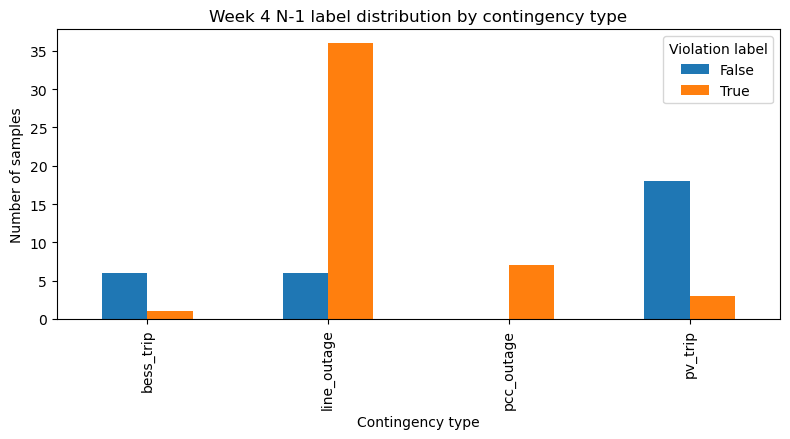

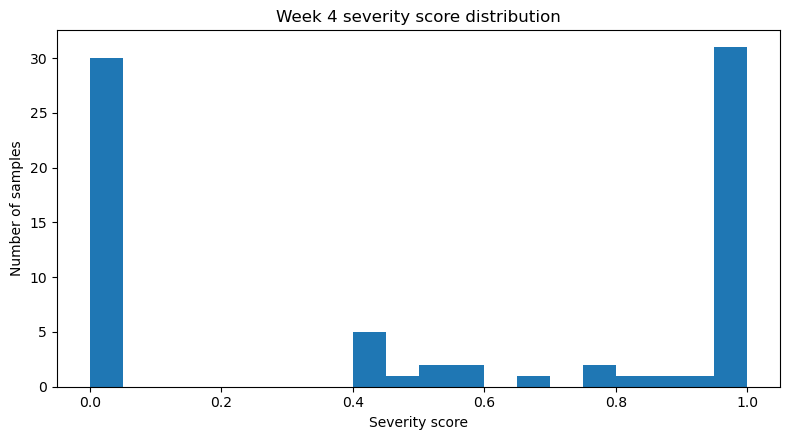

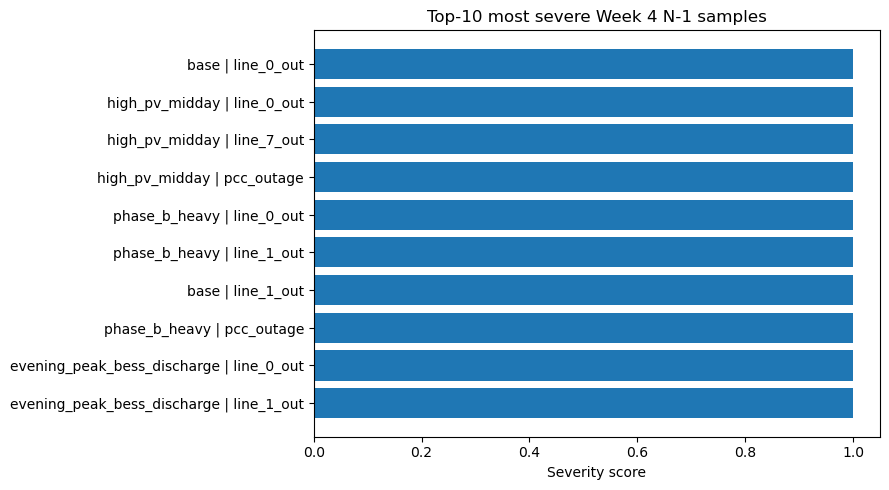

In [13]:
# Figure 1: label distribution by contingency type
fig, ax = plt.subplots(figsize=(8, 4.5))
pivot = label_distribution.pivot(index="contingency_type", columns="violation_label", values="count").fillna(0)
pivot.plot(kind="bar", ax=ax)
ax.set_title("Week 4 N-1 label distribution by contingency type")
ax.set_xlabel("Contingency type")
ax.set_ylabel("Number of samples")
ax.legend(title="Violation label")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "week4_label_distribution_by_type.png", dpi=180)
plt.show()

# Figure 2: severity distribution
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(n1_dataset["severity_score"], bins=20)
ax.set_title("Week 4 severity score distribution")
ax.set_xlabel("Severity score")
ax.set_ylabel("Number of samples")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "week4_severity_distribution.png", dpi=180)
plt.show()

# Figure 3: top severe samples
fig, ax = plt.subplots(figsize=(9, 5))
plot_data = top_severe.head(10).copy()
plot_data["sample"] = plot_data["scenario_id"] + " | " + plot_data["contingency_id"]
ax.barh(plot_data["sample"][::-1], plot_data["severity_score"][::-1])
ax.set_title("Top-10 most severe Week 4 N-1 samples")
ax.set_xlabel("Severity score")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "week4_top10_severe_samples.png", dpi=180)
plt.show()

## 10. Manual inspection cells

下面挑选四类代表性样本供学生检查：

1. safe PV trip；
2. line outage with downstream service loss；
3. PCC outage with no slack source；
4. stress scenario with high physical stress。

要求学生解释每个样本的 label 由哪个 physical metric 触发。

In [14]:
examples = []

safe_pv = n1_dataset[(n1_dataset.contingency_type == "pv_trip") & (~n1_dataset.violation_label.astype(bool))].head(1)
if len(safe_pv):
    examples.append(safe_pv)

line_loss = n1_dataset[(n1_dataset.contingency_type == "line_outage") & (n1_dataset.unserved_load_mw > SERVICE_LOSS_EPS_MW)].head(1)
if len(line_loss):
    examples.append(line_loss)

pcc_out = n1_dataset[n1_dataset.contingency_type == "pcc_outage"].head(1)
if len(pcc_out):
    examples.append(pcc_out)

stress = n1_dataset[n1_dataset.scenario_id == "stress_unbalance"].sort_values("severity_score", ascending=False).head(1)
if len(stress):
    examples.append(stress)

inspection_examples = pd.concat(examples, ignore_index=True)
inspection_cols = [
    "scenario_id", "contingency_id", "contingency_type", "element_name", "converged", "unserved_load_mw",
    "min_vm_pu", "max_line_loading_percent", "max_vuf_percent", *VIOLATION_FLAG_COLUMNS, "violation_label", "severity_score"
]
display(inspection_examples[inspection_cols].round(6))

,scenario_id,contingency_id,contingency_type,element_name,converged,unserved_load_mw,min_vm_pu,max_line_loading_percent,max_vuf_percent,voltage_low_violation,voltage_high_violation,loading_violation,vuf_violation,non_convergence_violation,service_loss_violation,critical_service_loss_violation,violation_label,severity_score
0,base,pv_0_trip,pv_trip,PV_single_phase_A,True,0.00000,0.979597,46.680118,0.123794,False,False,False,False,False,False,False,False,0.0
1,base,line_0_out,line_outage,L0_PCC_to_main,False,0.06800,NaN,NaN,NaN,False,False,False,False,False,True,True,True,1.0
2,base,pcc_outage,pcc_outage,PCC_slack_grid_connected,False,0.06800,NaN,NaN,NaN,False,False,False,False,True,True,True,True,1.0
3,stress_unbalance,line_0_out,line_outage,L0_PCC_to_main,False,0.13072,NaN,NaN,NaN,False,False,False,False,False,True,True,True,1.0


## How Week 4 connects to Week 5

Week 4 生成的是 label dataset。Week 5 训练传统 ML baseline 时，输入特征只能来自 **故障前可获得的信息**，例如：

- scenario parameters: load scale, phase factors, PV scale, BESS setpoint；
- base-case voltage / VUF / line loading；
- contingency type, element index, affected phase；
- 未来可扩展的 downstream load、electrical distance、local PV capacity 等。

不能把 `post_min_vm_pu`、`post_max_line_loading_percent`、`post_max_vuf_percent` 等 post-contingency ground-truth metrics 当作训练输入，否则会发生 label leakage。

## 11. 学生练习

1. 新增一个 `line_4_out` contingency，观察 PV_C branch outage 是否产生 service-loss label。
2. 把 `V_MIN_PU` 从 0.95 改为 0.98，比较 label distribution 是否变化。
3. 把 `VUF_MAX_PERCENT` 从 2% 改为 1%，观察 phase-heavy 和 stress scenario 的标签变化。
4. 新增一个 `transformer_outage` contingency 的数据结构，但暂时不运行，说明它需要哪些 pandapower element table。
5. 尝试把 `severity_score` 改成加权和，而不是 `max()`，并讨论 ranking 结果是否更合理。

下一周 Week 5 会直接读取 `week4_n1_dataset.csv`，训练第一版 ML baseline。


## 12. 本周小结：Week 4 产出什么？

Week 4 的核心产出是一个经过验证的三相 N-1 安全标签数据集：

$$
\mathcal{D}_{N-1}=\{(x_t,c_k,y_{t,k},s_{t,k})\}
$$

其中，每个样本都包含 scenario parameters、contingency metadata、post-contingency electrical metrics、topology-based service-loss metrics，以及各类 violation label。

下周 Week 5 将不再调用三相潮流，而是使用这里导出的 `week4_ai_ready_dataset.csv` 训练传统 ML baseline，并重点讨论 recall、false negative rate、AUPRC 和 threshold tuning。
